In [1]:
import torch
import cv2
from ultralytics import YOLO

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")

model = YOLO("yolov8s.pt")
print("Model loaded successfully")

PyTorch version: 2.8.0
GPU available:   False
Model loaded successfully


In [2]:
# test cell - technically is optional
import urllib.request

urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", "test_image.jpg")

results = model("test_image.jpg")
result  = results[0]

print("Quick test — objects found:")
for box in result.boxes:
    class_name = result.names[int(box.cls)]
    confidence = round(float(box.conf) * 100, 1)
    print(f"  - {class_name}: {confidence}%")


image 1/1 /Users/amulyaalaulkar/COM3025-CW/notebooks/test_image.jpg: 640x480 4 persons, 1 bus, 96.6ms
Speed: 2.8ms preprocess, 96.6ms inference, 5.3ms postprocess per image at shape (1, 3, 640, 480)
Quick test — objects found:
  - bus: 92.1%
  - person: 89.3%
  - person: 88.7%
  - person: 87.8%
  - person: 61.1%


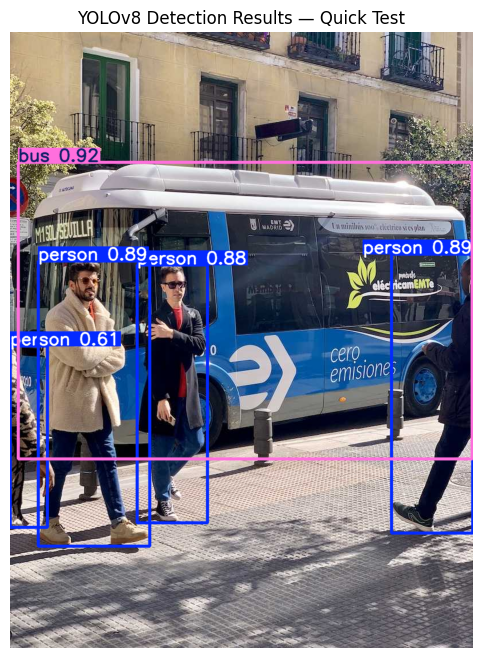

In [3]:
import matplotlib.pyplot as plt

annotated_image     = result.plot()
annotated_image_rgb = annotated_image[:, :, ::-1]  # fix BGR to RGB for display

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image_rgb)
plt.axis("off")
plt.title("YOLOv8 Detection Results — Quick Test")
plt.show()

In [4]:
CONFIDENCE_THRESHOLD = 0.5

print(f"Detections above {CONFIDENCE_THRESHOLD * 100}% confidence:")
print("-" * 40)

kept    = 0
removed = 0

for box in result.boxes:
    confidence = float(box.conf)
    class_name = result.names[int(box.cls)]

    if confidence < CONFIDENCE_THRESHOLD:
        removed += 1
        continue

    print(f"  - {class_name}: {round(confidence * 100, 1)}%")
    kept += 1

print("-" * 40)
print(f"Kept: {kept} detections ")
print(f"Removed: {removed} low-confidence detections")

Detections above 50.0% confidence:
----------------------------------------
  - bus: 92.1%
  - person: 89.3%
  - person: 88.7%
  - person: 87.8%
  - person: 61.1%
----------------------------------------
Kept: 5 detections 
Removed: 0 low-confidence detections


In [5]:
import os

output_path = "../data/detection_result.jpg"
annotated_save = result.plot()
cv2.imwrite(output_path, annotated_save)

print(f"Saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

Saved to: ../data/detection_result.jpg
File size: 361856 bytes


In [6]:
def run_detection(image_path, confidence=0.5, save_result=True):
    results          = model(image_path, conf=confidence, verbose=False)
    result           = results[0]
    detected_objects = [result.names[int(b.cls)] for b in result.boxes]
    annotated_image  = result.plot()
    result_path      = None

    if save_result:
        result_path = image_path.replace(".jpg", "_detected.jpg")
        cv2.imwrite(result_path, annotated_image)

    return detected_objects, annotated_image, result_path


# Quick test of the function
import os
if os.path.exists("test_image.jpg"):
    objects, image, saved = run_detection("test_image.jpg")
    print("run_detection() works correctly")
    print(f"Detected: {objects}")
else:
    print("run_detection() defined — run Cell 3 first to test it")

run_detection() works correctly
Detected: ['bus', 'person', 'person', 'person', 'person']


Camera opened — capturing photo in 2 seconds...
Photo captured


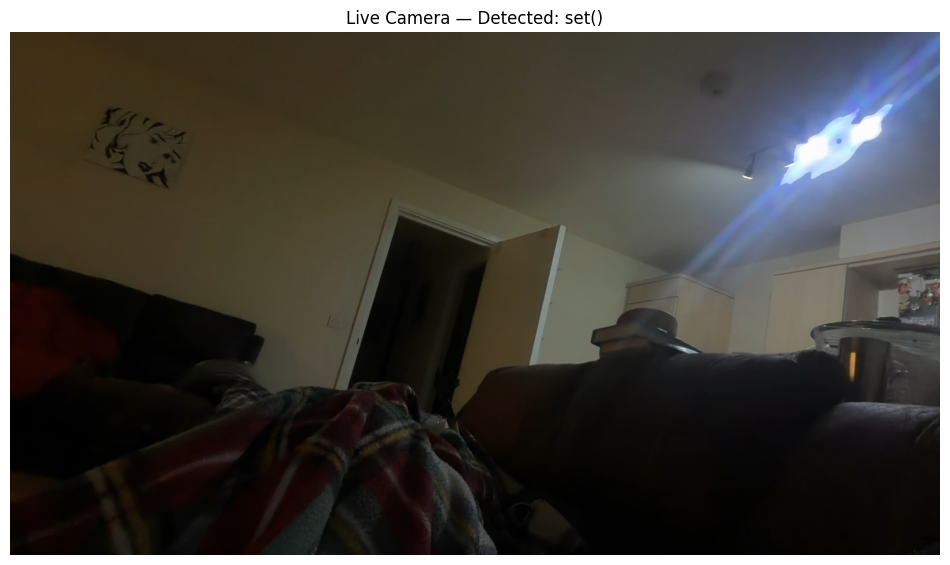

Objects found: []


In [7]:
import cv2
import matplotlib.pyplot as plt

# Open the webcam — 0 means the default camera on your laptop
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam — check it is connected and not in use")
else:
    print("Camera opened — capturing photo in 2 seconds...")

    # Let the camera warm up — read a few frames first
    for _ in range(10):
        cap.read()

    # Take the actual photo
    success, frame = cap.read()
    cap.release()  # always release the camera when done

    if not success:
        print("Failed to capture photo — try running the cell again")
    else:
        # Save the captured frame
        cv2.imwrite("../data/camera_capture.jpg", frame)
        print("Photo captured")

        # Run detection
        objects, annotated, saved = run_detection("../data/camera_capture.jpg")

        # Display result
        annotated_rgb = annotated[:, :, ::-1]
        plt.figure(figsize=(12, 8))
        plt.imshow(annotated_rgb)
        plt.axis("off")
        plt.title(f"Live Camera — Detected: {set(objects)}")
        plt.show()

        print(f"Objects found: {objects}")

# basic detection done, COCO dataset detection below


In [10]:
import os
import json
import csv
import time

IMAGE_FOLDER     = "../data/coco_test"
ANNOTATIONS_PATH = "../data/annotations/selected_annotations.json"
RESULTS_FILE     = "../data/detection_results.csv"
CONFIDENCE       = 0.5

# Load ground truth labels
with open(ANNOTATIONS_PATH) as f:
    ground_truth = json.load(f)

selected_images = list(ground_truth.keys())
print(f"Images to process: {len(selected_images)}")
print(f"Sample: {selected_images[:3]}\n")

# Set up CSV
with open(RESULTS_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "image_name",
        "num_detections",
        "objects_detected",
        "ground_truth_objects",
        "confidence_scores",
        "avg_confidence",
        "processing_time_ms"
    ])

print(f"Running detection on {len(selected_images)} images...")
print("-" * 50)

for i, filename in enumerate(selected_images):
    image_path = os.path.join(IMAGE_FOLDER, filename)

    start       = time.time()
    results_raw = model(image_path, conf=CONFIDENCE, verbose=False)
    end         = time.time()

    result_raw    = results_raw[0]
    processing_ms = round((end - start) * 1000, 1)
    objects       = [result_raw.names[int(b.cls)] for b in result_raw.boxes]
    confidences   = [round(float(b.conf) * 100, 1) for b in result_raw.boxes]
    avg_conf      = round(sum(confidences) / len(confidences), 1) if confidences else 0
    gt_objects    = ground_truth[filename]

    with open(RESULTS_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            filename,
            len(objects),
            ", ".join(objects) if objects else "none",
            ", ".join(gt_objects),
            ", ".join(str(c) for c in confidences) if confidences else "none",
            avg_conf,
            processing_ms
        ])

    print(f"  {i+1}/{len(selected_images)} — {filename} — found {len(objects)} — GT had {len(gt_objects)} — {processing_ms}ms")

print("-" * 50)
print(f"Done. Results saved to {RESULTS_FILE}")

Images to process: 50
Sample: ['000000002592.jpg', '000000003845.jpg', '000000002532.jpg']

Running detection on 50 images...
--------------------------------------------------
  1/50 — 000000002592.jpg — found 1 — GT had 3 — 168.8ms
  2/50 — 000000003845.jpg — found 6 — GT had 6 — 209.0ms
  3/50 — 000000002532.jpg — found 2 — GT had 2 — 206.4ms
  4/50 — 000000003156.jpg — found 2 — GT had 3 — 132.8ms
  5/50 — 000000003661.jpg — found 2 — GT had 3 — 151.5ms
  6/50 — 000000001761.jpg — found 2 — GT had 2 — 132.1ms
  7/50 — 000000005037.jpg — found 4 — GT had 3 — 97.9ms
  8/50 — 000000001532.jpg — found 5 — GT had 2 — 92.2ms
  9/50 — 000000001584.jpg — found 5 — GT had 2 — 121.1ms
  10/50 — 000000002149.jpg — found 4 — GT had 2 — 78.8ms
  11/50 — 000000002923.jpg — found 2 — GT had 2 — 81.7ms
  12/50 — 000000001268.jpg — found 6 — GT had 6 — 105.1ms
  13/50 — 000000004795.jpg — found 2 — GT had 3 — 149.1ms
  14/50 — 000000002006.jpg — found 4 — GT had 4 — 90.5ms
  15/50 — 000000001353.jp

In [9]:
import csv

total_detections = 0
all_times = []
object_counts = []

with open(RESULTS_FILE) as f:
    reader = csv.DictReader(f)
    for row in reader:
        total_detections += int(row["num_detections"])
        all_times.append(float(row["processing_time_ms"]))
        object_counts.append(int(row["num_detections"]))

total_images = len(object_counts)

print("── Results Summary ──────────────────")
print(f"Images processed:      {total_images}")
print(f"Total detections:      {total_detections}")
print(f"Avg detections/image:  {round(total_detections/total_images, 1)}")
print(f"Avg processing time:   {round(sum(all_times)/len(all_times), 1)}ms")
print(f"Fastest image:         {min(all_times)}ms")
print(f"Slowest image:         {max(all_times)}ms")
print(f"Most objects in one image: {max(object_counts)}")
print(f"Images with 0 detections:  {object_counts.count(0)}")

── Results Summary ──────────────────
Images processed:      50
Total detections:      208
Avg detections/image:  4.2
Avg processing time:   88.6ms
Fastest image:         65.9ms
Slowest image:         177.4ms
Most objects in one image: 15
Images with 0 detections:  1
